# LOS coverage analysis

For a regular raster of candidate transmitter locations (at a fixed height), this notebook computes how many sensing units (SUs) are in line-of-sight (LOS). The LOS check is done via ray tracing with `max_depth=0`, i.e., only the direct path between a candidate location and each SU is considered.

In [14]:
import os
import sys

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import yaml

import sionna.rt as srt

# import own modules
_repo_name = "ofdma-spectrum-anomalies-simulation"
_module_path = os.getcwd()[: os.getcwd().find(_repo_name) + len(_repo_name)]
sys.path.append(os.path.join(os.path.abspath(_module_path), "src"))

from utils.rt_utils import (
    init_scene,
    get_su_coordinates,
    get_scene_size,
    configure_tx_antenna_pattern,
    enclosed_in_obstacle
)

In [10]:
scene_nr = 0
f_c = 3.75e9  # in Hz, matches src/conf/dataset_generation.yaml

GRID_STEP = 0.5  # raster spacing in m
TX_HEIGHT = 1.5  # height of the candidate transmitter locations in m
MARGIN = 0.05  # margin to the walls in m, to avoid placing points directly on them
CHUNK_SIZE = 10  # number of candidate TX locations simulated per ray tracing call

In [11]:
su_coordinates = get_su_coordinates(_module_path)

scene_path = os.path.join(_module_path, "scenes", f"scene{scene_nr}", "scene.xml")
scene = init_scene(scene_path, f_c, su_coordinates)
scene_size = get_scene_size(scene)

print(f"Scene size: {scene_size}")
print(f"Number of sensing units: {len(su_coordinates)}")

Scene size: [40. 40.  5.]
Number of sensing units: 21


## Compute LOS coverage

This ray traces every valid raster point (points enclosed within an obstacle are skipped and kept as `NaN`) against all SUs. For `scene0` (40 x 40 m) at 0.5 m spacing, this takes a few minutes.

In [15]:
def compute_los_coverage_grid(
    scene,
    scene_nr,
    scene_size,
    grid_step=0.5,
    tx_height=1.5,
    margin=0.05,
    chunk_size=5,
    p_solver=None,
):
    """Compute the number of sensing units in line-of-sight (LOS) for a regular raster.

    A regular x-y raster of candidate transmitter locations is placed at a
    fixed height. For every raster point that is not enclosed within an
    obstacle, the number of sensing units (added to the scene as receivers)
    that are in LOS is determined via ray tracing (LOS-only, i.e., depth 0).

    Parameters
    ----------
    scene : sionna.rt.Scene
        Scene object with the sensing units already added as receivers
        (e.g., as returned by init_scene).
    scene_nr : int
        Index of the current scene, required to check whether a raster
        point is enclosed within an obstacle.
    scene_size : tuple
        Size of the scene, as returned by get_scene_size.
    grid_step : float, optional
        Spacing of the raster in meters. Default: 0.5.
    tx_height : float, optional
        Height of the candidate transmitter locations. Default: 1.5.
    margin : float, optional
        Margin to the scene boundary (walls) in meters, to avoid placing
        candidate locations directly on a wall. Default: 0.05.
    chunk_size : int, optional
        Number of candidate transmitters added to the scene at once for a
        single ray tracing call. Default: 500.
    p_solver : sionna.rt.PathSolver, optional
        Path solver to be used. If not specified, a new one is created.

    Returns
    -------
    grid_df : pandas.DataFrame
        DataFrame with columns x, y, z and num_su_los, containing the raster
        point coordinates and the number of sensing units in LOS. Raster
        points enclosed within an obstacle are kept with num_su_los = NaN.
    """

    if p_solver is None:
        p_solver = srt.PathSolver()

    x_vals = np.arange(margin, scene_size[0] - margin, grid_step)
    y_vals = np.arange(margin, scene_size[1] - margin, grid_step)
    xx, yy = np.meshgrid(x_vals, y_vals, indexing="ij")
    grid_points = np.stack(
        [xx.ravel(), yy.ravel(), np.full(xx.size, tx_height)], axis=1
    )

    num_su_los = np.full(grid_points.shape[0], np.nan)

    valid_idx = np.array(
        [i for i, pt in enumerate(grid_points) if not enclosed_in_obstacle(pt, scene_nr)]
    )

    scene = configure_tx_antenna_pattern(scene, "iso")

    for start in tqdm(
        range(0, len(valid_idx), chunk_size), desc="Computing LOS coverage"
    ):
        batch_idx = valid_idx[start : start + chunk_size]
        tx_names = [f"tx_grid{i}" for i in range(len(batch_idx))]
        for name, pt_idx in zip(tx_names, batch_idx):
            scene.add(srt.Transmitter(name=name, position=grid_points[pt_idx]))

        paths = p_solver(
            scene=scene,
            max_depth=0,
            los=True,
            specular_reflection=False,
            diffuse_reflection=False,
            refraction=False,
            diffraction=False,
        )
        # paths.valid has shape [num_su, num_tx_in_batch, num_paths]
        valid_paths = np.asarray(paths.valid)
        num_su_los[batch_idx] = valid_paths.any(axis=2).sum(axis=0)

        for name in tx_names:
            scene.remove(name)

    grid_df = pd.DataFrame(
        {
            "x": grid_points[:, 0],
            "y": grid_points[:, 1],
            "z": grid_points[:, 2],
            "num_su_los": num_su_los,
        }
    )

    return grid_df


In [16]:
grid_df = compute_los_coverage_grid(
    scene,
    scene_nr,
    scene_size,
    grid_step=GRID_STEP,
    tx_height=TX_HEIGHT,
    margin=MARGIN,
    chunk_size=CHUNK_SIZE,
)
grid_df.head()

Computing LOS coverage:   0%|          | 0/506 [00:00<?, ?it/s]

,x,y,z,num_su_los
0,0.05,0.05,1.5,6.0
1,0.05,0.55,1.5,5.0
2,0.05,1.05,1.5,5.0
3,0.05,1.55,1.5,5.0
4,0.05,2.05,1.5,5.0


In [21]:
print(np.nanmedian(grid_df["num_su_los"]))
print(grid_df["num_su_los"].describe())

7.0
count    5056.000000
mean        6.594146
std         2.903975
min         0.000000
25%         5.000000
50%         7.000000
75%        10.000000
max        11.000000
Name: num_su_los, dtype: float64


In [ ]:
save_results = True
if save_results:
    csv_path = os.path.join(
        _module_path, "figures", f"los_coverage_scene{scene_nr}.csv"
    )
    grid_df.to_csv(csv_path, index=False)
    print(f"Saved results to {csv_path}")

## Visualization

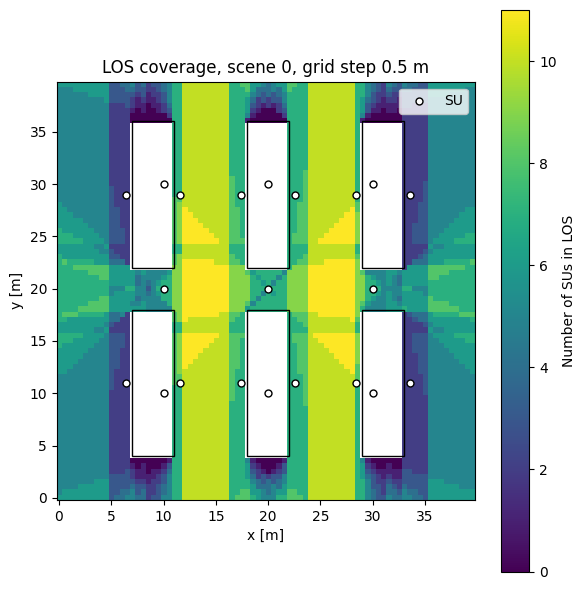

In [22]:
fig, ax = plt.subplots(figsize=(6, 6))

heatmap = grid_df.pivot(index="y", columns="x", values="num_su_los")
mesh = ax.pcolormesh(
    heatmap.columns, heatmap.index, heatmap.values, shading="nearest", cmap="viridis"
)
fig.colorbar(mesh, ax=ax, label="Number of SUs in LOS")

# overlay the obstacles
scene_attr_path = os.path.join(
    _module_path, "scenes", f"scene{scene_nr}", "scene_attributes.yaml"
)
with open(scene_attr_path, "r") as file:
    scene_description = yaml.safe_load(file)

for obstacle in scene_description.get("obstacles", {}).values():
    x, y = obstacle["anchor_point"][:2]
    w, l = obstacle["edge_length"][:2]
    rect = patches.Rectangle(
        (x, y), w, l, linewidth=1, edgecolor="black", facecolor="none"
    )
    ax.add_patch(rect)

# overlay the sensing units
su_coords = np.array(su_coordinates)
ax.scatter(
    su_coords[:, 0],
    su_coords[:, 1],
    c="white",
    edgecolors="black",
    marker="o",
    s=25,
    label="SU",
)

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal")
ax.set_title(f"LOS coverage, scene {scene_nr}, grid step {GRID_STEP} m")
ax.legend(loc="upper right")

plt.tight_layout()
# plt.savefig(os.path.join(_module_path, "figures", f"los_coverage_scene{scene_nr}.pdf"))
plt.show()

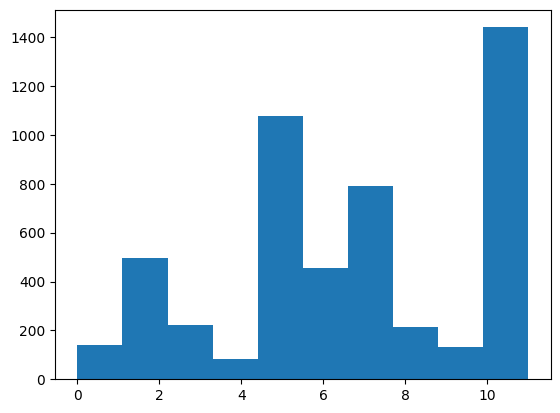

In [ ]:
plt.hist(grid_df["num_su_los"].dropna(),);

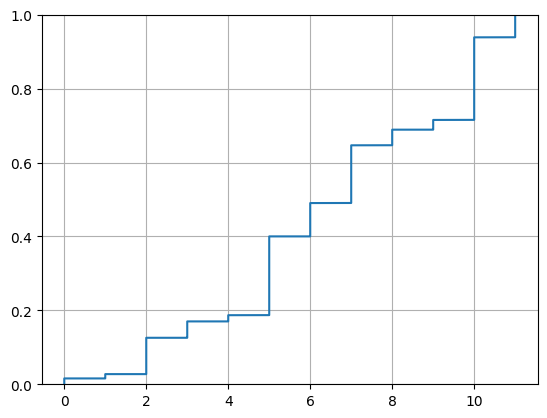

In [27]:
plt.ecdf(grid_df["num_su_los"].dropna())
plt.grid()